In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [24]:
df = yf.download('AAPL', start='2023-01-01', end='2025-12-31')
close = df['Close']['AAPL']
df

/tmp/ipykernel_975/1668406774.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2023-01-01', end='2025-12-31')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,122.982719,128.715417,122.097738,128.105769,112117500
2023-01-04,124.251183,126.512801,122.992546,124.772336,89113600
2023-01-05,122.933556,125.637661,122.677900,125.008343,80962700
2023-01-06,127.456764,128.115581,122.805707,123.907018,87754700
2023-01-09,127.977936,131.183540,127.722280,128.292603,70790800
...,...,...,...,...,...
2025-12-23,271.854919,271.994674,269.060124,270.337749,29642000
2025-12-24,273.302216,274.919206,271.695216,271.834940,17910600


In [25]:
ma20 = close.rolling(20).mean()
ma50 = close.rolling(50).mean()

In [26]:
signal = []
position = []
ma20_arr = np.array(ma20)
ma50_arr = np.array(ma50)

signal = np.where(ma20_arr > ma50_arr, 1, 0)
signal = pd.Series(signal, index=close.index)

position = signal.diff()
print(position)

Date
2023-01-03    NaN
2023-01-04    0.0
2023-01-05    0.0
2023-01-06    0.0
2023-01-09    0.0
             ... 
2025-12-23    0.0
2025-12-24    0.0
2025-12-26    0.0
2025-12-29    0.0
2025-12-30    0.0
Length: 751, dtype: float64


In [27]:
daily_market_return = close.pct_change()
daily_market_return

,AAPL
Date,
2023-01-03,NaN
2023-01-04,0.010314
2023-01-05,-0.010605
2023-01-06,0.036794
2023-01-09,0.004089
...,...
2025-12-23,0.005130
2025-12-24,0.005324
2025-12-26,-0.001497


In [32]:
strategy_return = daily_market_return * signal.shift(1)
strategy_return

,0
Date,
2023-01-03,NaN
2023-01-04,0.000000
2023-01-05,-0.000000
2023-01-06,0.000000
2023-01-09,0.000000
...,...
2025-12-23,0.005130
2025-12-24,0.005324
2025-12-26,-0.001497


In [36]:
cumulative_market_return = (1 + daily_market_return).cumprod()
cumulative_strategy_return = (1 + strategy_return).cumprod()
print(f"Total return of buy-and-hold: {cumulative_market_return.iloc[-1]:.2%}")
print(f"Total return of MA strategy: {cumulative_strategy_return.iloc[-1]:.2%}")

Total return of buy-and-hold: 221.64%
Total return of MA strategy: 152.91%


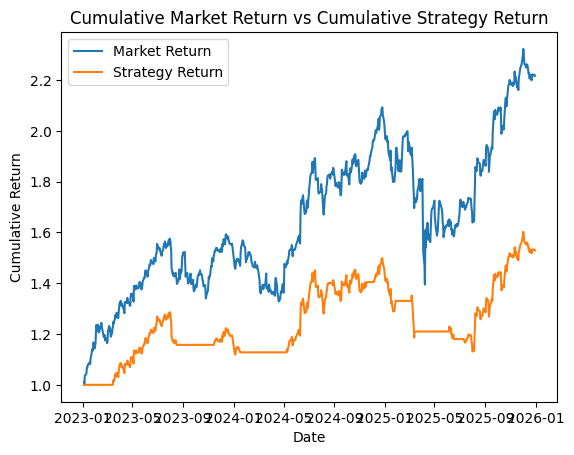

In [37]:
plt.plot(cumulative_market_return, label='Market Return')
plt.plot(cumulative_strategy_return, label='Strategy Return')
plt.title("Cumulative Market Return vs Cumulative Strategy Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()

In [38]:
# Buy-and-hold significantly outperformed the MA crossover strategy —
# 221.64% vs 152.91% over 2023-2025.

# MA crossover underperformed because the signal lags price — by the time
# MA20 crosses MA50, the move has already happened. In a strong bull trend,
# buy-and-hold captures every day of gains while the crossover strategy
# misses the early part of each upswing.

# Limitation: this backtest ignores transaction costs, slippage, and
# real-world events (earnings, macro shocks) that could invalidate
# the signal entirely — past performance does not guarantee future results.